In [ ]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import vis_utils

sys.path.append('/gpfs01/berens/user/hzhang/eff-ph')
from utils.utils import get_path
from utils.io_utils import load_multiple_res
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print, plot_edges_on_scatter
from utils.pd_utils import sort_cycle

sys.path.append('/gpfs01/berens/user/hzhang/eff-ph/vis_utils')
from vis_utils.loaders import load_dataset
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from vis_utils.tsne_wrapper import TSNEwrapper


from vis_utils.total_variation import reshape_dist, total_variation_matrix, complete_linkage, turn_to_partition, pic_pigeonhole_loops




from openTSNE.affinity import Affinities

import umap
from ripser import Rips
from ripser.ripser import get_greedy_perm

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
import glasbey
import scipy.sparse
import networkx as nx

from sklearn.decomposition import PCA
from sklearn.manifold import MDS

from persim import plot_diagrams
from utils.pd_utils import get_life_times
import pandas as pd
from collections import Counter

from sklearn.decomposition import PCA
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import community as community_louvain


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUDA_VISIBLE_DEVICES=1


# load distribution

In [4]:
style_file = "utils.style"
plt.style.use(style_file)

In [5]:
distances = {
    "euclidean": [{}],
    "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
    ],
}

In [ ]:
file_name = os.path.join(get_path("data"),
                         "tasic",
                         f"tsne_bin_k_15_n_epochs_500_n_early_epochs_250_seed_0_init_pca_rescale_True.pkl")
tsne_data = load_dict(file_name)
embd_tasic = tsne_data["embds"][-1]


In [10]:
file_name = os.path.join(get_path("data"),
                         "yao_smart",
                         f"tsne_bin_k_15_n_epochs_500_n_early_epochs_250_seed_0_init_pca_rescale_True.pkl")
tsne_data = load_dict(file_name)
embd_yao = tsne_data["embds"][-1]

In [12]:
root_path = get_path("data")

In [13]:
smart_mask_purple = np.load(os.path.join(root_path,"smart_mask_purple.npy"))
tasic_mask_purple = np.load(os.path.join(root_path,"tasic_mask_purple.npy"))
embd_purple_10x = np.load(os.path.join(root_path,"embd_x_mask_purple_sample.npy"))

In [14]:
dist_tasic_purple = load_dict(os.path.join(root_path, "dist_tasic_purple.pkl"))
dist_yao_purple = load_dict(os.path.join(root_path, "dist_yao_purple.pkl"))
dist_10x_purple = load_dict(os.path.join(root_path, "dist_10x_purple.pkl"))

In [18]:
ticks, reshape_tasic_purple = reshape_dist(dist_tasic_purple,7)
_, reshape_yao_purple = reshape_dist(dist_yao_purple,7)
_, reshape_10x_purple = reshape_dist(dist_10x_purple,7)


# 10x purple * 10x purple

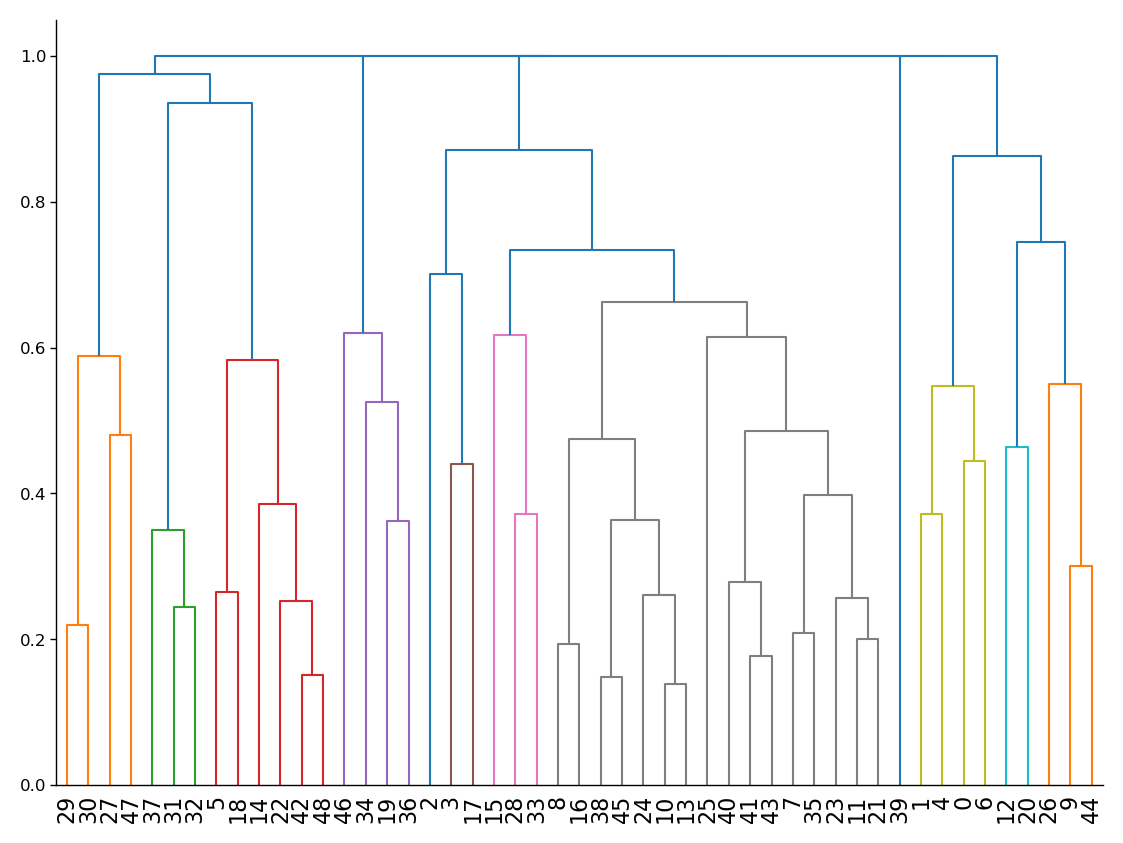

In [37]:
mat = total_variation_matrix(reshape_10x_purple, reshape_10x_purple)
clusters, list_of_communities = complete_linkage(mat, threshold =0.8)
partition = turn_to_partition(list_of_communities)


Done with yao_10x_male_purple_sample None euclidean n_outliers=0, perturbation=None
Done with yao_10x_male_purple_sample None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_sample None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_sample None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_sample None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_sample None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_male_purple_sample None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


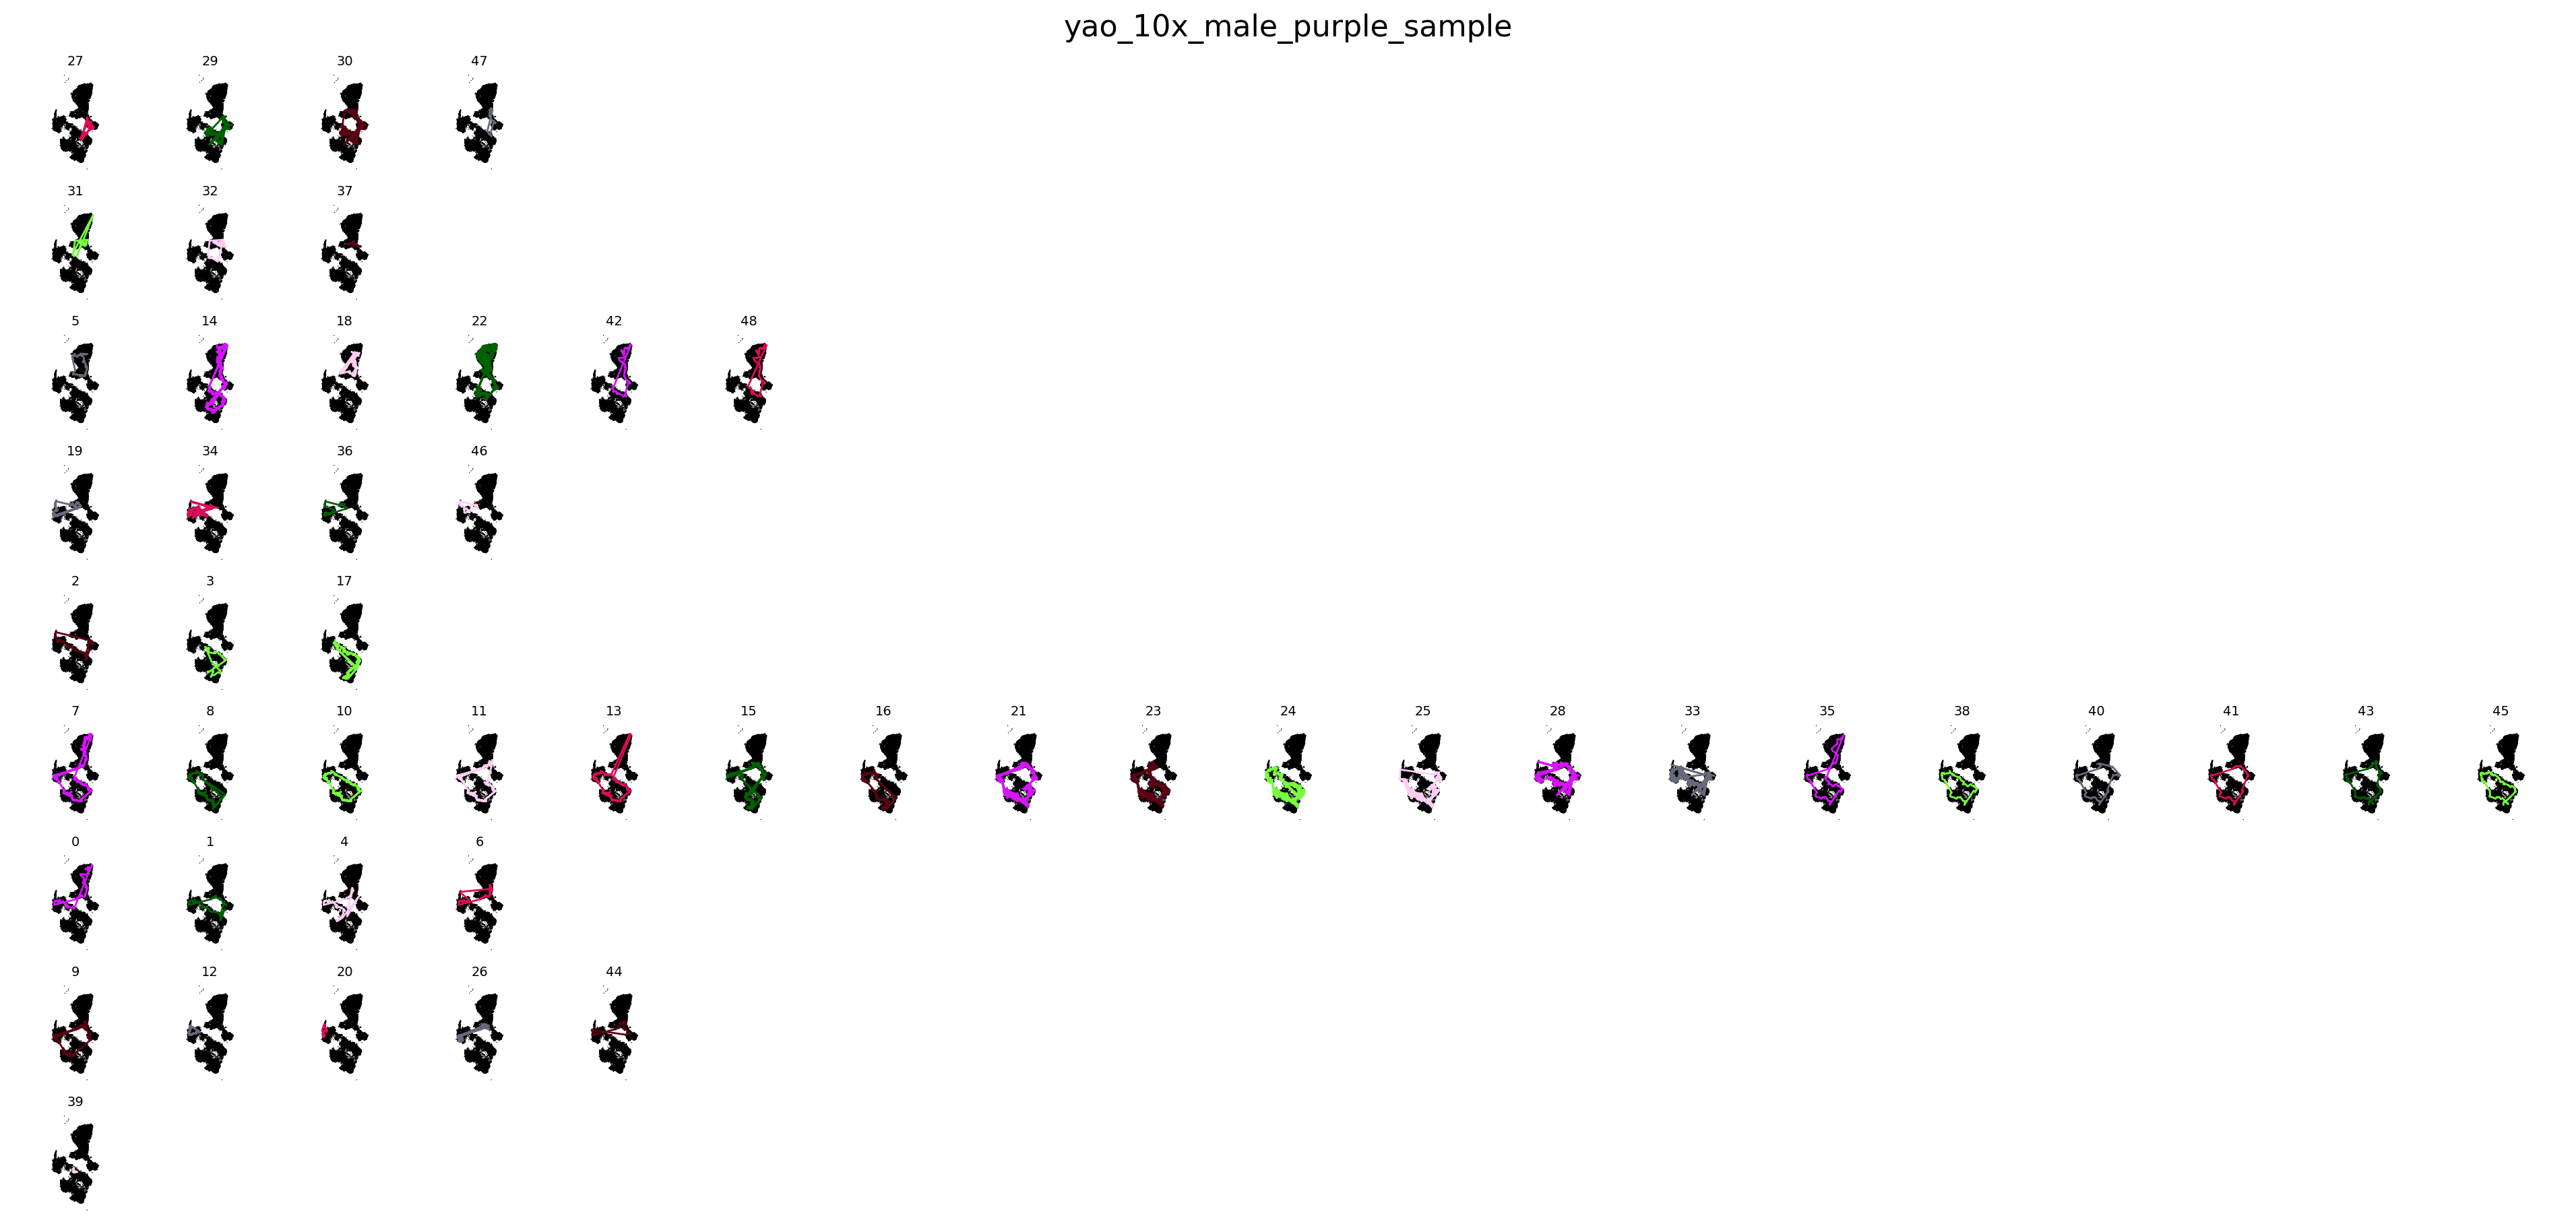

In [51]:
pic_pigeonhole_loops(partition, "yao_10x_male_purple_sample", embd_purple_10x, distances, xlim = None, ylim = None) # saveas = "pic_10x_purple.png"

# tri purple

In [335]:
mat_tasic = total_variation_matrix(reshape_tasic_purple, reshape_tasic_purple)
mat_yao = total_variation_matrix(reshape_yao_purple, reshape_yao_purple)
mat_10x = total_variation_matrix(reshape_10x_purple, reshape_10x_purple)
mat_t_y = total_variation_matrix(reshape_tasic_purple, reshape_yao_purple)
mat_t_10 = total_variation_matrix(reshape_tasic_purple, reshape_10x_purple)
mat_y_10 = total_variation_matrix(reshape_yao_purple, reshape_10x_purple)

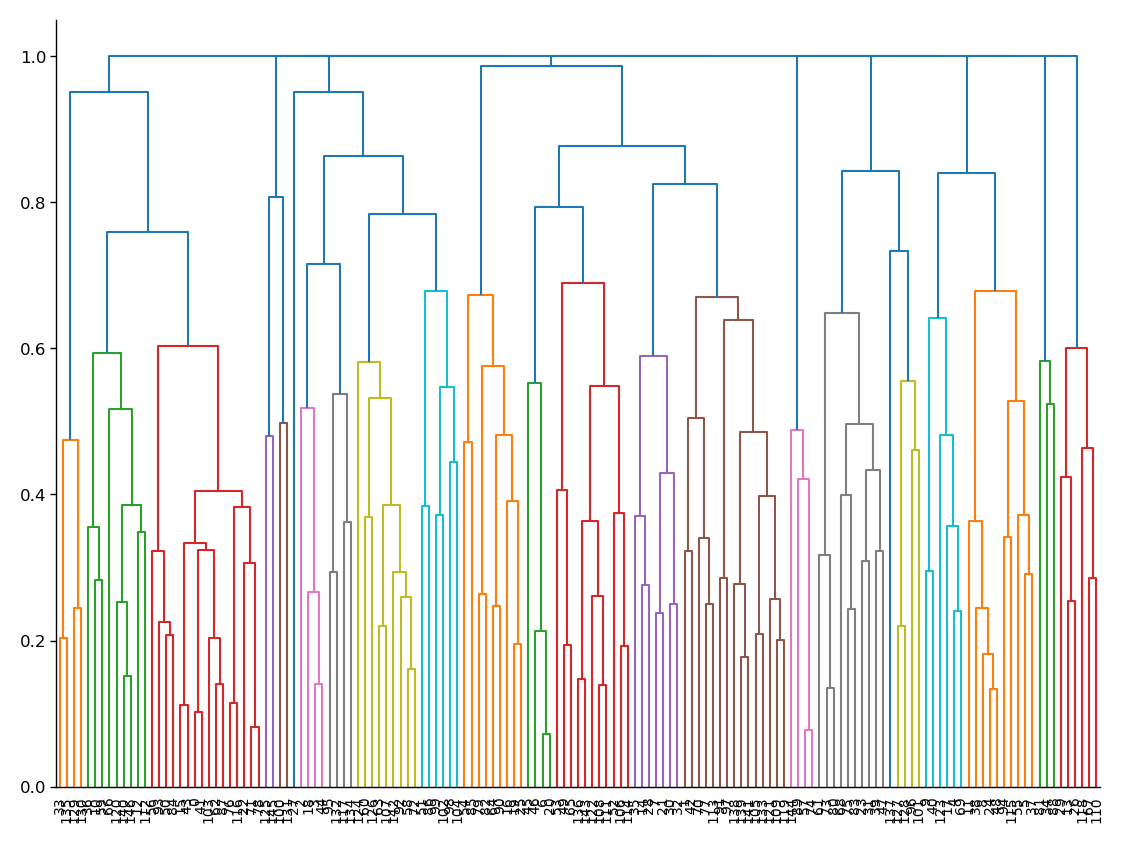

In [336]:
partition, trim_list_of_communities = complete_linkage_tri(threshold = 0.75)

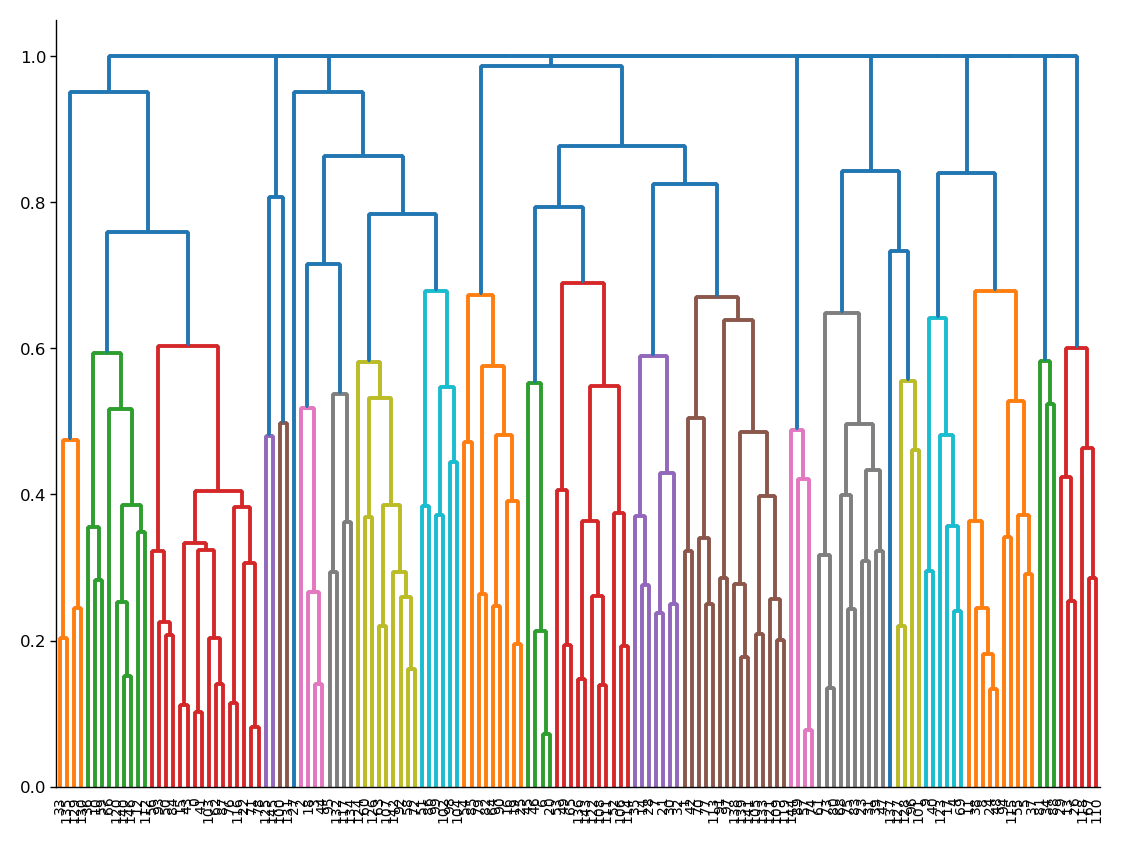

In [30]:
tri_mat, ave_tv, n_tv =tune_tri_threshold()

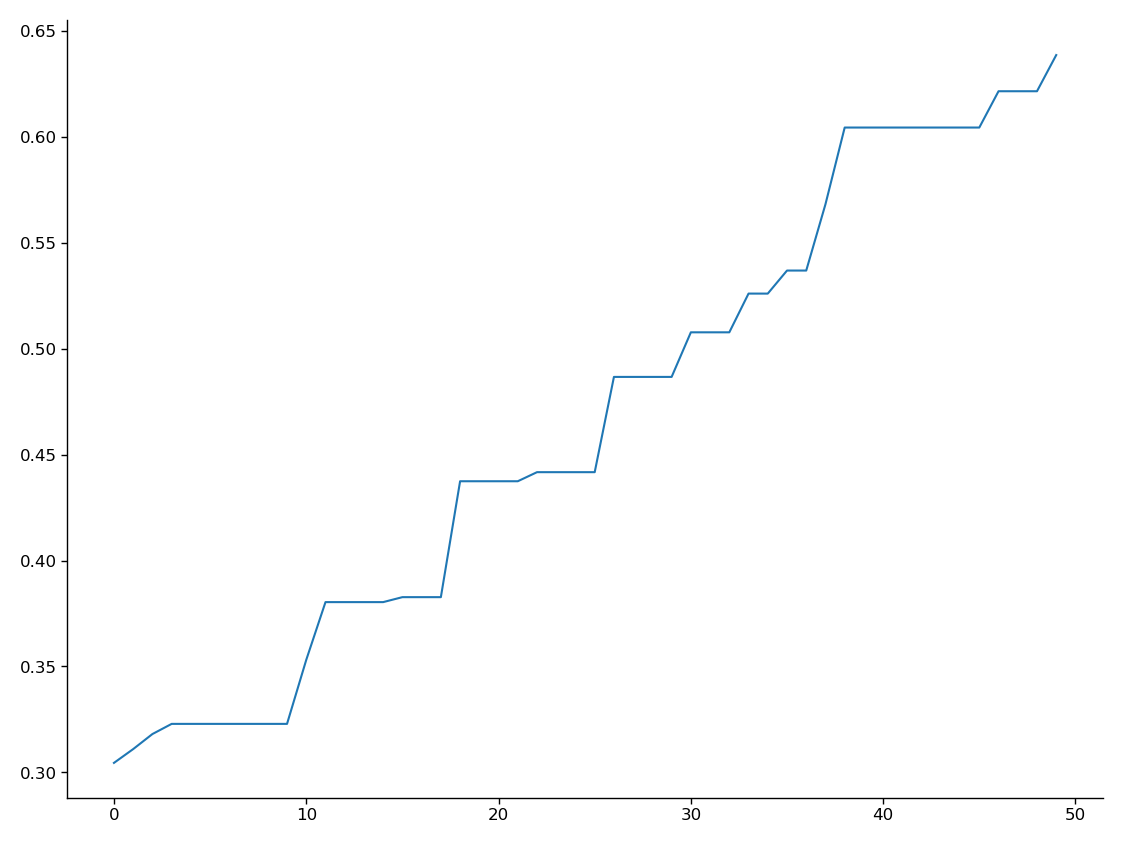

In [31]:
plt.plot(np.arange(0, len(ave_tv), 1), ave_tv)

In [32]:
trim_list_of_communities

[[10, 12, 36, 59, 66, 112, 120, 140, 146],
 [0, 15, 22, 41, 43, 50, 56, 62, 71, 76, 78, 84, 87, 93, 103, 116],
 [2, 3, 18, 44, 95, 117, 132, 134],
 [1, 42, 70, 77, 91, 97, 105, 109, 113, 119, 121, 133, 138, 139, 141],
 [4, 9, 17, 40, 69, 123],
 [5, 8, 11, 24, 37, 38, 48, 55, 94, 115],
 [13, 26, 29, 67, 110, 118],
 [[33, 129, 130, 135],
  [125, 145],
  [100, 131],
  [58, 60, 63, 72, 92, 107, 124, 126, 142],
  [51, 86, 98, 99, 102, 104],
  [27],
  [16, 19, 25, 54, 64, 79, 82, 85, 90],
  [6, 20, 45, 46],
  [49, 52, 53, 65, 106, 108, 111, 114, 122, 136, 143],
  [7, 14, 21, 28, 30, 32, 35],
  [57, 74, 89, 144],
  [23, 31, 39, 47, 61, 68, 73, 75, 80, 83],
  [96, 101, 127, 128, 137],
  [34, 81, 88]]]

Done with tasic_purple_lamp5 None euclidean n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None
Done with yao_smart_purple None euclidean n_outliers=0, perturbation=None
Done with yao_smart_purple None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_sma

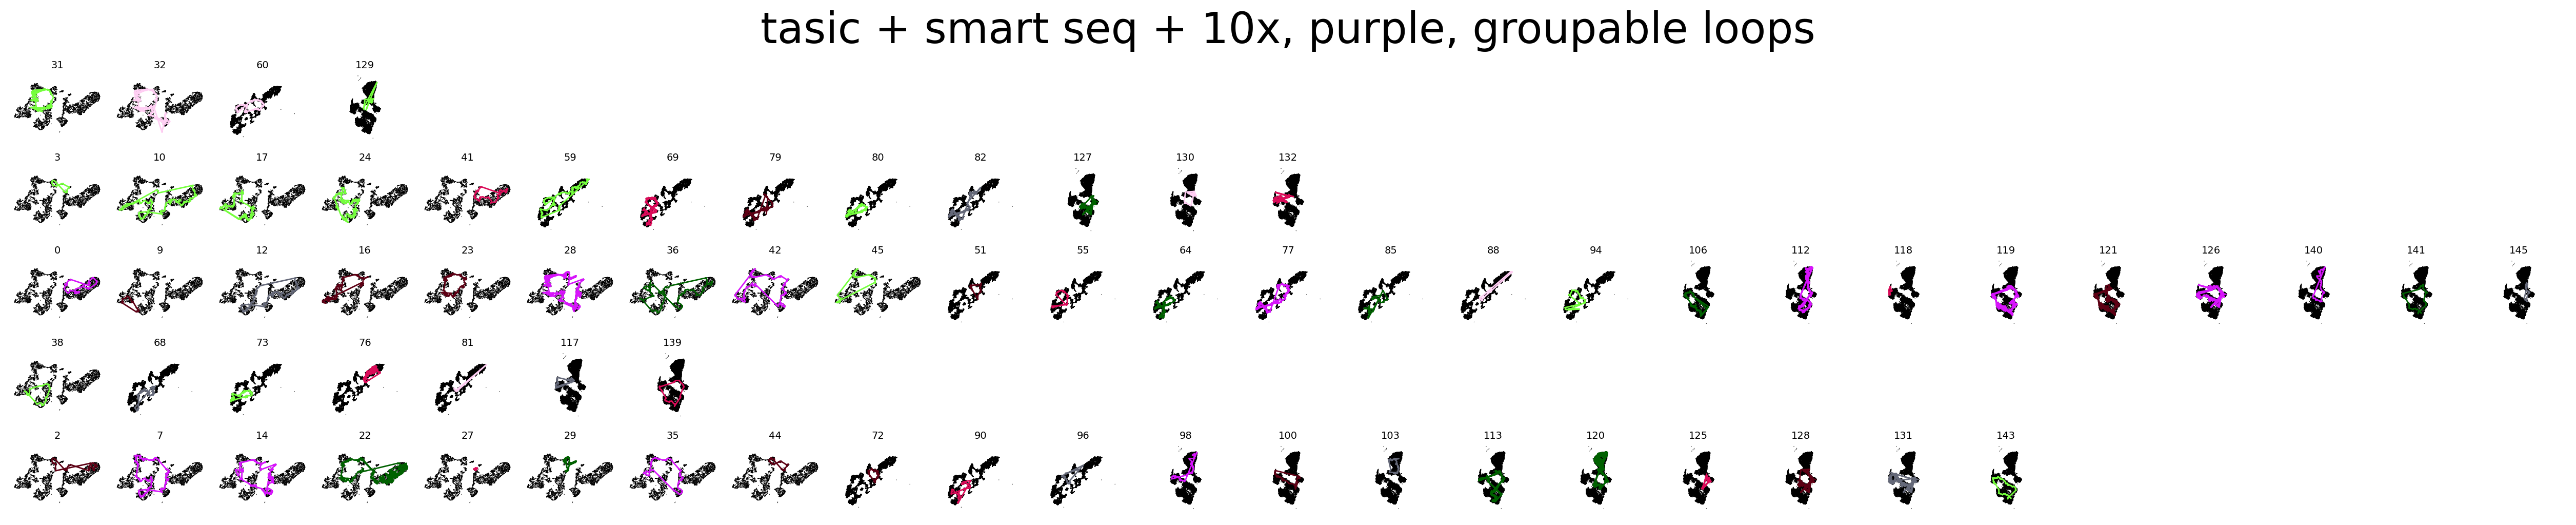

In [387]:
pic_tri_pigeonhole_loops(partition, trim_list_of_communities,ticks,  "tasic_purple_lamp5", "yao_smart_purple", "yao_10x_male_purple_sample", "purple", saveas = "purple_fig_tri.png")

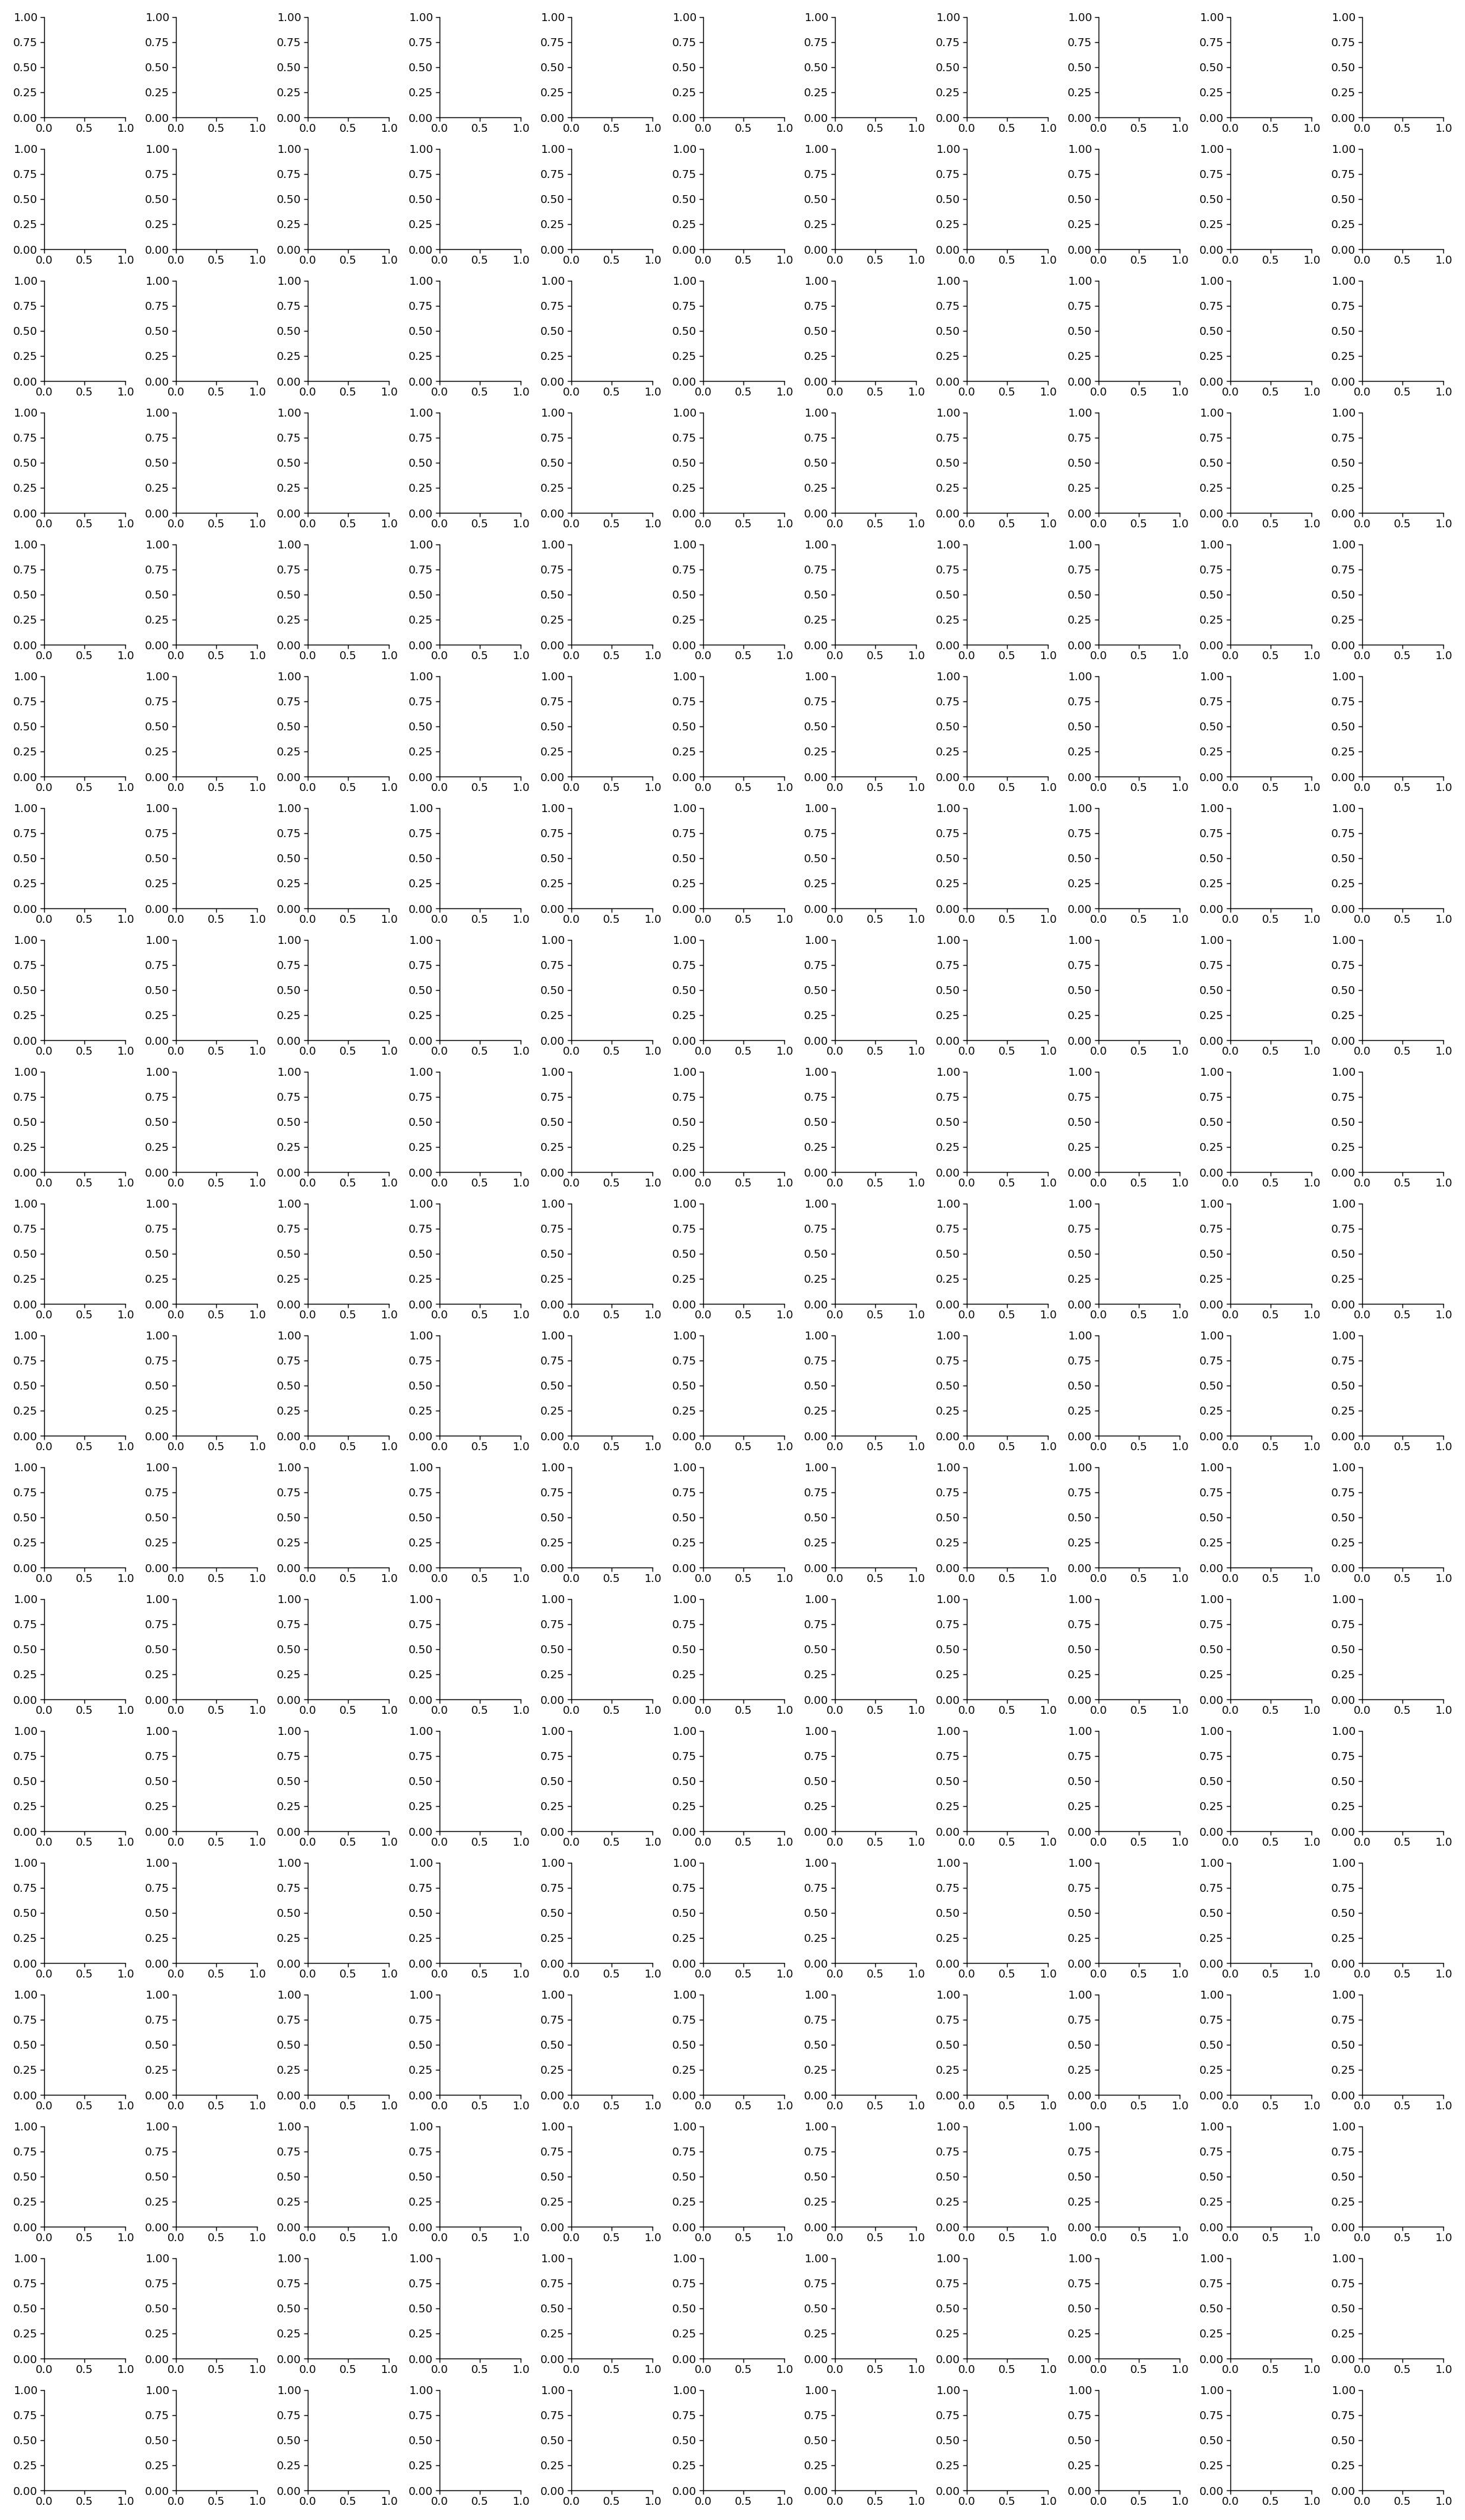

In [ ]:
pic_tri_unpigeonhole_loops(partition, trim_list_of_communities,ticks,  "tasic_purple_lamp5", "yao_smart_purple", "yao_10x_male_purple_20k", "purple", saveas = "purple_fig_tri_ungro.png")

# passing cells......!!!!!!

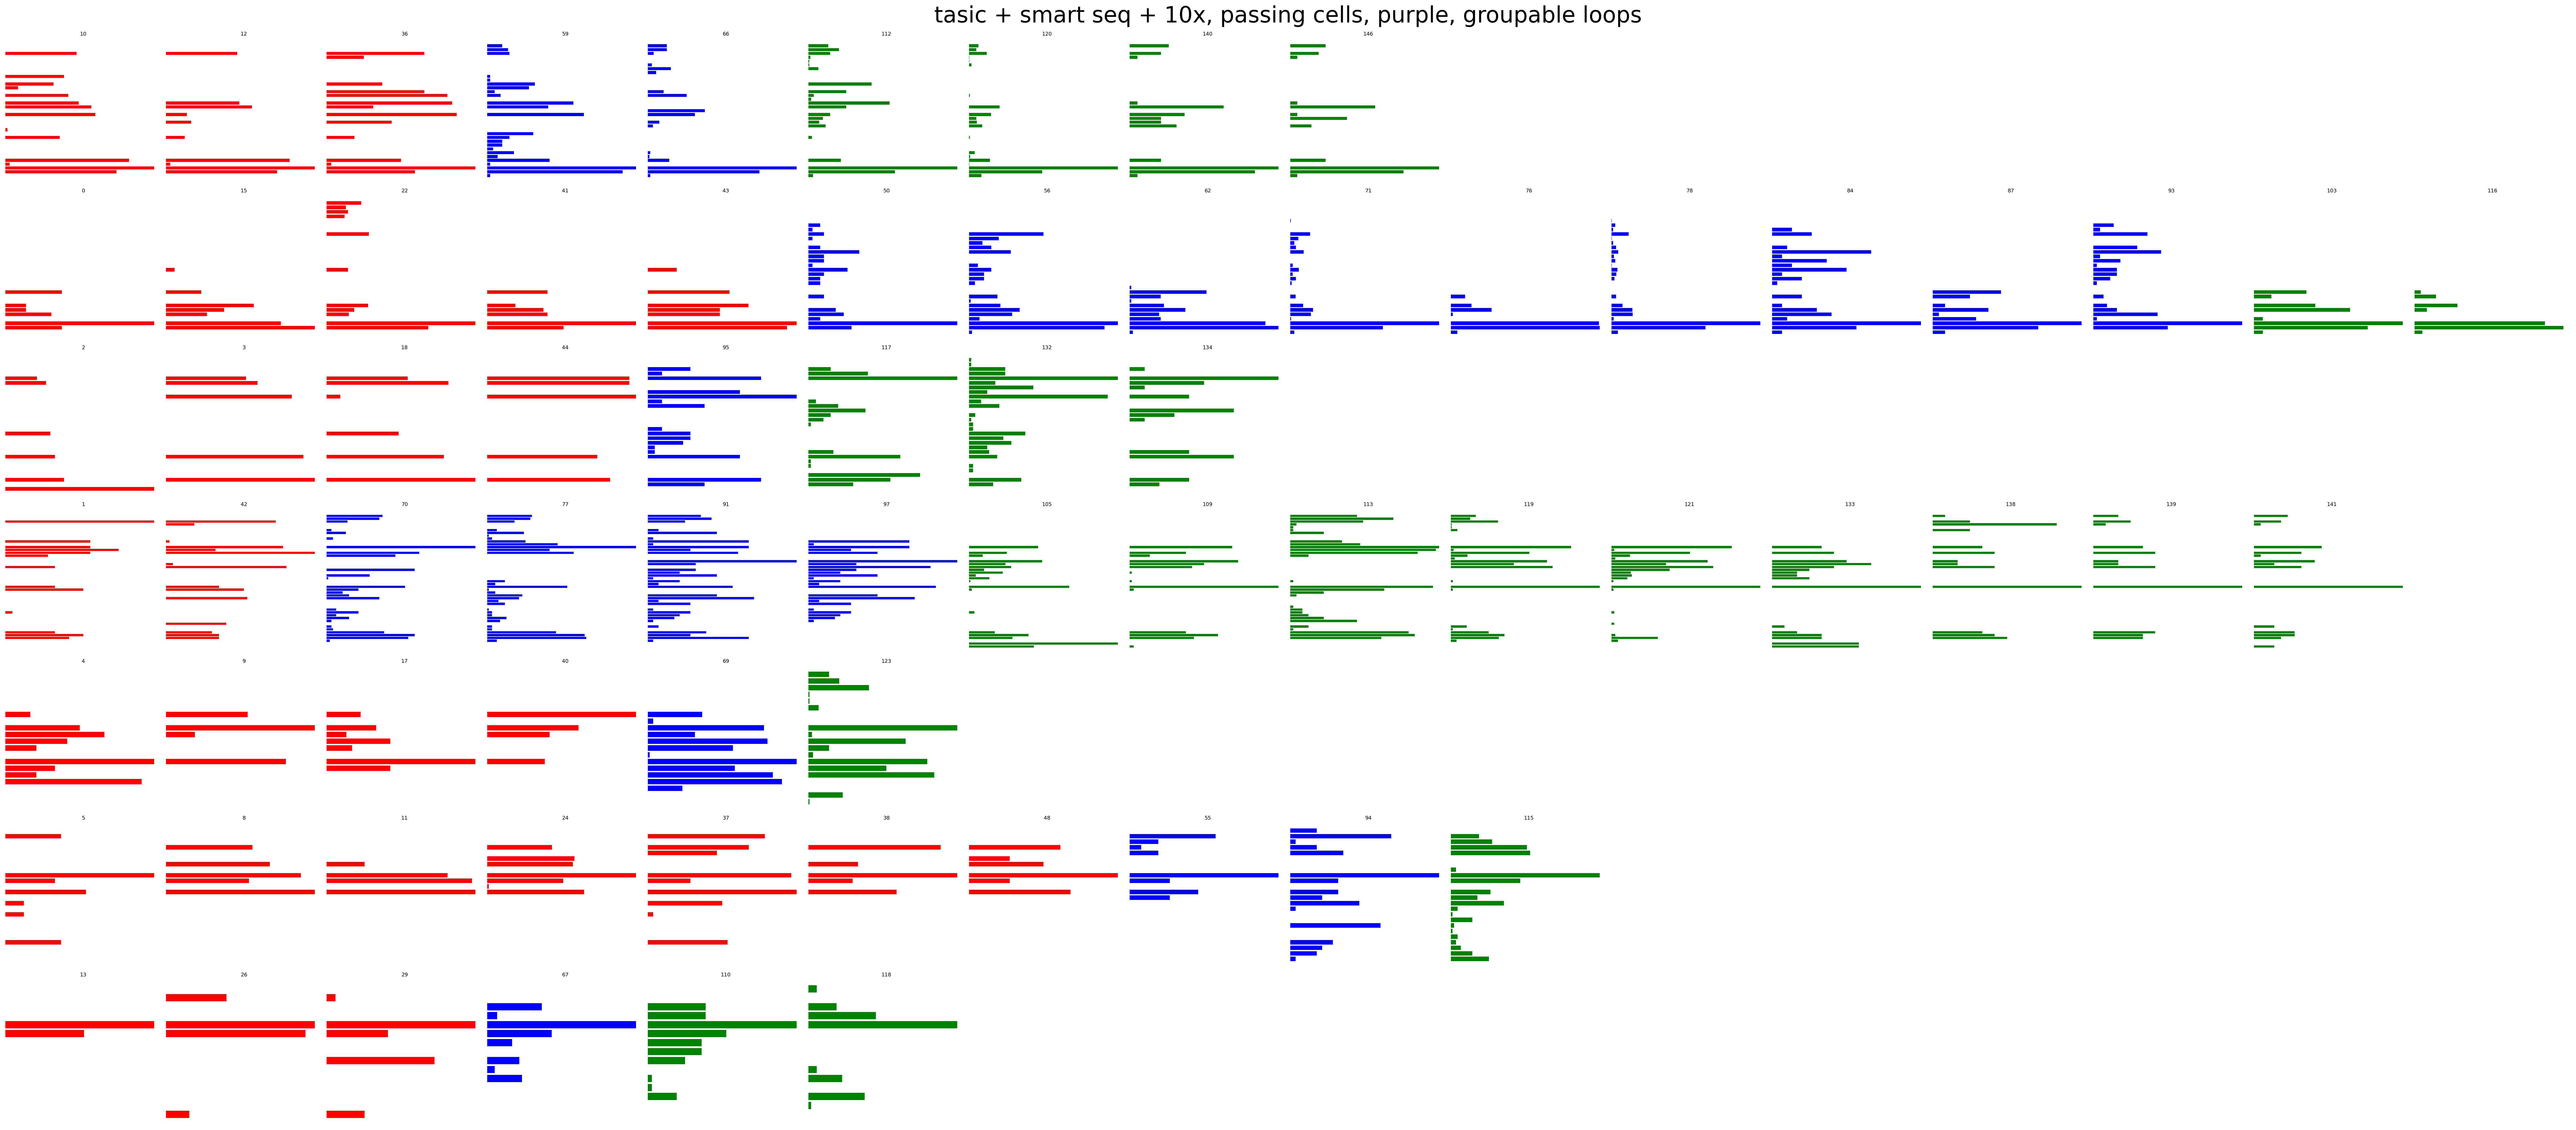

In [129]:
his_tri_pigeonhole_loops(partition, trim_list_of_communities, dist_tasic_purple, dist_yao_purple, dist_10x_purple, "purple")

In [385]:
def his_tri_pigeonhole_loops(partition, trim_list_of_communities, dist_tasic, dist_yao, dist_10x, cell_group, saveas = None):
    
    rows = len(trim_list_of_communities)-1
    columns = np.max([list(partition.values()).count(value) for value in range(rows)])
    
    cluster_color = list(dist_tasic.keys())[0]
    clusters = np.array(dist_tasic[cluster_color]) #should be the same.....
    conditions = list(dist_tasic.keys())[1:]
    
    fig, ax = plt.subplots(rows, columns, figsize=(columns*1, rows*1), constrained_layout=True)

    # colors = ['#d714fb', '#006100', '#5d0014', '#75ff3d', '#ffcef3', '#656979', '#db0c59']
    colors = ["red", "blue", "green"]
    
    for row, l in enumerate(trim_list_of_communities[:-1]):
        distributions = []
        for idx in l:
            condition = conditions[int(np.floor((idx%49)/7))]
            if idx<49 :
                distributions.append(dist_tasic[condition][idx%7])
            elif idx >= 40 and idx < 98:
                distributions.append(dist_yao[condition][idx%7])
            elif idx >= 98:
                distributions.append(dist_10x[condition][idx%7])
            
        distributions = np.vstack(distributions)
        
        nonzeros = np.sum(distributions, axis = 0)
        nonzeros_idx = np.where(nonzeros > 0)[0]
        filtered_clusters = clusters[nonzeros_idx]
        filtered_distributions = distributions[:,nonzeros_idx]

        for col, idx in enumerate(l):
            cax = ax[row][col]
            cax.set_title(idx, fontsize=7)
            
            cax.barh(filtered_clusters, filtered_distributions[col,:], color=colors[int(np.floor((idx)/49))]) #, tick_label = filtered_clusters
            # cax.barh(filtered_clusters, filtered_distribution, color=colors[idx%7])

    for axx in ax.flat:
        axx.axis('off')
    # ax[10][0].set_title("                                    ungroupable loops", fontsize=30)
    fig.suptitle(f"tasic + smart seq + 10x, passing cells, {cell_group}, groupable loops", fontsize = 30)       
    plt.show()
    if saveas is not None:
        fig.savefig(os.path.join("/gpfs01/berens/user/hzhang/eff-ph/figures", saveas), dpi=300)
